# Batch Cost Escalation — Predictive Classification

## Project Objective
Predict how severe a production batch's cost overrun will be — early enough for the operations team to step in and prevent it.

The target variable has four severity levels: **Normal → Watch → High → Critical**

## Data Available
| File | What it contains | Size |
|---|---|---|
| `production_batches.csv` | One row per batch — process metrics, dates, and the target label | 5,050 rows |
| `supplier_quality.csv` | Monthly supplier performance by product category | 3,780 rows |

## Approach
1. **Data Cleaning & Leakage Removal** — Fix data quality issues; remove columns that would cheat the model
2. **Merging Production & Supplier Data** — Combine both datasets at the right level of detail
3. **Descriptive & Inferential Statistics** — Understand the data; statistically confirm which features matter
4. **Feature Engineering** — Create new, more meaningful variables from existing ones
5. **Model Building & Comparison** — Train and compare three classifiers
6. **Stability Validation** — Confirm results hold up across different data splits

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, f1_score, recall_score,
    ConfusionMatrixDisplay, balanced_accuracy_score
)

pd.set_option('display.max_columns', 50)

RANDOM_STATE  = 42
TARGET_ORDER  = ['Normal', 'Watch', 'High', 'Critical']
TARGET_COLORS = ['#4C9F70', '#E1B84C', '#E07B39', '#C0392B']

---
## Section 1 — Data Loading & Cleaning

**What we do here:** Load both datasets, check for data quality issues (duplicates, missing values), and remove columns/features that would give the model an unfair advantage.

**Why this matters:** A model trained on dirty data or on information that only exists after a batch is complete will not work in the real world. This section ensures the data is trustworthy before any analysis begins.

In [101]:
production = pd.read_csv('production_batches.csv')
supplier   = pd.read_csv('supplier_quality.csv')

print(f'Production : {production.shape[0]:,} rows x {production.shape[1]} columns')
print(f'Supplier   : {supplier.shape[0]:,} rows x {supplier.shape[1]} columns')

Production : 5,050 rows x 17 columns
Supplier   : 3,780 rows x 8 columns


---
Column names and all string fields were standardized by trimming leading and trailing whitespaces to prevent inconsistencies during duplicate detection, merging, and categorical encoding.

In [102]:
# Step 0: Standardize column names and remove whitespace

# Strip column names
production.columns = production.columns.str.strip()
supplier.columns   = supplier.columns.str.strip()

# Strip whitespace from all string/object columns
for df in [production, supplier]:
    for col in df.select_dtypes(include='object'):
        df[col] = df[col].astype(str).str.strip()

print("Whitespace cleanup completed.")

Whitespace cleanup completed.


### 1.1 — Duplicate Check & Removal

**What:** Identify and remove rows that appear more than once.

**Two types of duplicates found in production data:**
- **Full-row duplicates** — exact copies across every column (47 found)
- **Batch_ID duplicates** — same batch ID, but one row has a missing `Energy_Consumption_kWh` (3 found)

**How we handle each:**
- Full duplicates → keep the first occurrence, drop the rest
- Batch_ID duplicates → keep the row that has the actual energy value, drop the blank one

In [103]:
print('Production — full-row duplicates :', production.duplicated().sum())
print('Production — Batch_ID duplicates :', production.duplicated(subset=['Batch_ID']).sum())
print('Supplier   — full-row duplicates :', supplier.duplicated().sum())
print('Supplier   — key duplicates       :', supplier.duplicated(subset=['Supplier_ID','Product_Category','Month']).sum())

Production — full-row duplicates : 47
Production — Batch_ID duplicates : 50
Supplier   — full-row duplicates : 0
Supplier   — key duplicates       : 0


In [104]:
# Step 1: Remove full-row duplicates
production = production.drop_duplicates(keep='first').reset_index(drop=True)
print(f'After removing full-row duplicates: {production.shape}')

After removing full-row duplicates: (5003, 17)


In [105]:
# Show which Batch_IDs still appear more than once
pd.set_option('display.max_rows', None)
production[production.duplicated(subset=['Batch_ID'], keep=False)].head(10)

,Batch_ID,Production_Date,Plant_ID,Product_Category,Supplier_ID,Shift,Batch_Size,Planned_Cost,Scrap_Rate,Rework_Hours,Machine_Downtime_Hours,Energy_Consumption_kWh,Temperature_C,Post_Overrun_Amount,Post_Inspection_Score,Post_Warranty_Claim_Flag,Cost_Escalation_Level
180,B001096,2025-11-18,PLT06,C,SUP0078,Night,800,104158.40,0.1040,1.95,3.50,1275.0,37.4,14632.08,76.0,0,Normal
204,B004456,2025-12-12,PLT09,A,SUP0162,Day,712,71641.85,0.0476,5.92,5.56,519.3,25.9,10615.37,74.9,0,Normal
725,B004456,2025-12-12,PLT09,A,SUP0162,Day,712,71641.85,0.0476,5.92,5.56,NaN,25.9,10615.37,74.9,0,Normal
2083,B003825,2025-01-02,PLT05,A,SUP0137,Day,1878,165073.85,0.0945,9.22,1.67,1430.4,32.0,28684.50,74.6,0,Watch
3457,B003825,2025-01-02,PLT05,A,SUP0137,Day,1878,165073.85,0.0945,9.22,1.67,NaN,32.0,28684.50,74.6,0,Watch
4225,B001096,2025-11-18,PLT06,C,SUP0078,Night,800,104158.40,0.1040,1.95,3.50,NaN,37.4,14632.08,76.0,0,Normal


In [106]:
# Step 2: For Batch_ID duplicates — sort so non-null energy values come first, then keep first per Batch_ID
production = (
    production
    .sort_values('Energy_Consumption_kWh', na_position='last')
    .drop_duplicates(subset=['Batch_ID'], keep='first')
    .reset_index(drop=True)
)
print(f'After Batch_ID dedup : {production.shape}')
print(f'Remaining duplicates : {production.duplicated(subset=["Batch_ID"]).sum()}')

After Batch_ID dedup : (5000, 17)
Remaining duplicates : 0


### 1.2 — Missing Value Treatment

**What:** Find columns with missing data and decide how to handle them.

**Finding:** All missing values are below 5% of total rows — safe to drop those rows without losing meaningful data.

In [107]:
null_summary = production.isna().sum()
null_summary = null_summary[null_summary > 0].to_frame('count')
null_summary['pct %'] = (null_summary['count'] / len(production) * 100).round(2)
print('Columns with missing values (all under 5%):')
print(null_summary)

n_before   = len(production)
production = production.dropna().reset_index(drop=True)
print(f'\nRows dropped : {n_before - len(production)}')
print(f'Final shape  : {production.shape}')

Columns with missing values (all under 5%):
                        count  pct %
Rework_Hours               41   0.82
Machine_Downtime_Hours     48   0.96
Energy_Consumption_kWh     72   1.44
Temperature_C             201   4.02

Rows dropped : 355
Final shape  : (4645, 17)


### 1.3 — Leakage Removal

**What is leakage?** Some columns only exist *after* the batch is complete. Using them to predict cost escalation is like checking tomorrow's newspaper to predict today's events — it works in training but fails in real life.


In [108]:
leakage_cols = ['Post_Overrun_Amount', 'Post_Inspection_Score', 'Post_Warranty_Claim_Flag']

print('Average values by escalation level — confirms these are post-batch outcomes:')
print(production.groupby('Cost_Escalation_Level')[leakage_cols].mean().loc[TARGET_ORDER].round(2))

production = production.drop(columns=leakage_cols)
print(f'\nShape after leakage removal: {production.shape}')

Average values by escalation level — confirms these are post-batch outcomes:
                       Post_Overrun_Amount  Post_Inspection_Score  \
Cost_Escalation_Level                                               
Normal                            24159.04                  75.46   
Watch                             32167.74                  72.93   
High                              41162.23                  71.52   
Critical                          50108.91                  69.99   

                       Post_Warranty_Claim_Flag  
Cost_Escalation_Level                            
Normal                                     0.06  
Watch                                      0.06  
High                                       0.09  
Critical                                   0.07  

Shape after leakage removal: (4645, 14)


**Which columns are removed and why:**

| Column | Why it's removed |
|---|---|
| `Post_Overrun_Amount` | This IS the cost overrun — it directly determines the target variable |
| `Post_Inspection_Score` | Quality score assigned after the batch is finished |
| `Post_Warranty_Claim_Flag` | Warranty claims are filed after delivery, not during production |

**Proof of leakage:** The table below shows the values for: `Post_Overrun_Amount` rises and `Post_Inspection_Score` falls perfectly with `Cost_Escalation_Level` — confirming they are outcomes, not inputs.

### 1.4 — Date Type Conversion

In [109]:
# Convert to datetime and extract month (needed for the join in Section 2)
production['Production_Date'] = pd.to_datetime(production['Production_Date'])
production['Month'] = production['Production_Date'].dt.month

---
## Section 2 — Merging Production & Supplier Data

**What we do here:** Combine both datasets so every production batch also carries its supplier's performance metrics for that month.

**Why a left join?** We want to keep all production batches, even if some suppliers have no quality record. A missing supplier record is itself a risk signal — so we flag and fill those gaps rather than dropping those batches.

**How the join works:** Match on three keys — `Supplier_ID` + `Product_Category` + `Month` — because a supplier's performance can vary by product type and changes month to month.

In [110]:
# Confirm supplier keys are unique before joining
assert supplier.duplicated(subset=['Supplier_ID','Product_Category','Month']).sum() == 0

prod_sups = set(production['Supplier_ID'].unique())
sup_sups  = set(supplier['Supplier_ID'].unique())
print(f'Suppliers in production with no quality record: {len(prod_sups - sup_sups)} out of {len(prod_sups)}')

merged = production.merge(supplier, how='left', on=['Supplier_ID','Product_Category','Month'])
merged['has_supplier_data'] = merged['Defect_Rate'].notna().astype(int)

assert len(merged) == len(production), 'Row count changed after join'

print(f'Shape after merge : {merged.shape}')
print(f'Supplier coverage : {merged["has_supplier_data"].mean()*100:.1f}%')

Suppliers in production with no quality record: 70 out of 250
Shape after merge : (4645, 21)
Supplier coverage : 90.9%


In [111]:
# Fill missing supplier metrics using the median for that product category + month
# Why median? It is not affected by extreme values, unlike the mean
sup_numeric = ['Defect_Rate','On_Time_Delivery_Rate','Avg_Lead_Time_Days','Supplier_Risk_Score']

for col in sup_numeric:
    merged[col] = merged.groupby(['Product_Category','Month'])[col].transform(lambda s: s.fillna(s.median()))

merged['Audit_Flag'] = merged['Audit_Flag'].fillna('Unknown')

print(f'Residual nulls after imputation: {merged.isna().sum().sum()}')

Residual nulls after imputation: 0


### 2.1 — Post-Merge Dataset Profile

Quick verification of the merged dataset's shape, column types, and descriptive statistics.

In [112]:
print('Shape:', merged.shape)
print('\nColumn types:')
print(merged.dtypes)
print('\nDescriptive statistics:')
merged.describe().T

Shape: (4645, 21)

Column types:
Batch_ID                          object
Production_Date           datetime64[ns]
Plant_ID                          object
Product_Category                  object
Supplier_ID                       object
Shift                             object
Batch_Size                         int64
Planned_Cost                     float64
Scrap_Rate                       float64
Rework_Hours                     float64
Machine_Downtime_Hours           float64
Energy_Consumption_kWh           float64
Temperature_C                    float64
Cost_Escalation_Level             object
Month                              int32
Defect_Rate                      float64
On_Time_Delivery_Rate            float64
Avg_Lead_Time_Days               float64
Supplier_Risk_Score              float64
Audit_Flag                        object
has_supplier_data                  int64
dtype: object

Descriptive statistics:


,count,mean,min,25%,50%,75%,max,std
Production_Date,4645,2025-07-02 11:54:15.888051712,2025-01-01 00:00:00,2025-04-05 00:00:00,2025-07-03 00:00:00,2025-09-29 00:00:00,2025-12-31 00:00:00,NaN
Batch_Size,4645.0,1431.104844,416.0,1065.0,1347.0,1702.0,4766.0,520.007195
Planned_Cost,4645.0,177414.71504,35597.84,120962.04,161211.47,215671.52,825042.71,79425.103169
Scrap_Rate,4645.0,0.088649,0.0005,0.0714,0.0878,0.1048,0.2446,0.025547
Rework_Hours,4645.0,5.412517,0.12,2.49,4.5,7.31,30.69,3.946986
Machine_Downtime_Hours,4645.0,4.346943,0.05,2.13,3.64,5.74,39.56,3.129722
Energy_Consumption_kWh,4645.0,1512.666545,326.1,1041.5,1382.2,1822.6,7005.9,666.076103
Temperature_C,4645.0,27.529882,12.0,23.8,27.5,31.2,48.0,5.566726
Month,4645.0,6.542519,1.0,4.0,7.0,9.0,12.0,3.413722
Defect_Rate,4645.0,0.046835,0.005518,0.037394,0.045973,0.053168,0.25,0.019013


---
## Section 3 — Descriptive Statistics & Exploratory Analysis

**What we do here:** Understand the data visually and numerically — how the target is distributed, which features vary the most, and which show clear separation across severity levels.

**Why before modelling?** EDA reveals class imbalance, feature behaviour, and potential predictors — all of which directly shape modelling decisions.

### 3.1 — Target Distribution

**What:** How many batches fall into each severity level?

**Why it matters:** If one class (e.g. Normal) is far more common than others, a naive model will just predict Normal every time and still look accurate. This imbalance must be handled explicitly in the modelling step.

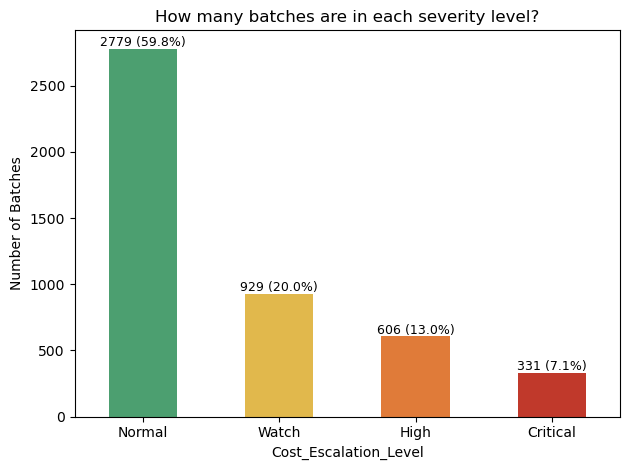

In [113]:
counts = merged['Cost_Escalation_Level'].value_counts().reindex(TARGET_ORDER)

counts.plot(kind='bar', color=TARGET_COLORS)
plt.title('How many batches are in each severity level?')
plt.ylabel('Number of Batches')
plt.xticks(rotation=0)

for i, v in enumerate(counts):
    plt.text(i, v + 20, f'{v} ({v/len(merged)*100:.1f}%)', ha='center', fontsize=9)

plt.savefig('batch_in_severity.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

### 3.2 — Numeric Feature Variance Analysis

**What:** Summary statistics for every numeric feature.

**Which metric to watch:** `CV%` (Coefficient of Variation) = standard deviation / mean x 100. A high CV% means the feature varies a lot relative to its typical value — making it a stronger candidate predictor.

In [114]:
numeric_cols = [
    'Batch_Size','Planned_Cost','Scrap_Rate','Rework_Hours',
    'Machine_Downtime_Hours','Energy_Consumption_kWh','Temperature_C',
    'Defect_Rate','On_Time_Delivery_Rate','Avg_Lead_Time_Days','Supplier_Risk_Score'
]

var_df = merged[numeric_cols].agg(['mean','std','var','skew']).T.round(3)
var_df.columns = ['Mean','Std','Variance','Skewness']
var_df['CV%'] = (var_df['Std'] / var_df['Mean'].abs() * 100).round(1)
print(var_df)

                              Mean        Std      Variance  Skewness   CV%
Batch_Size                1431.105    520.007  2.704075e+05     1.210  36.3
Planned_Cost            177414.715  79425.103  6.308347e+09     1.431  44.8
Scrap_Rate                   0.089      0.026  1.000000e-03     0.365  29.2
Rework_Hours                 5.413      3.947  1.557900e+01     1.473  72.9
Machine_Downtime_Hours       4.347      3.130  9.795000e+00     1.930  72.0
Energy_Consumption_kWh    1512.667    666.076  4.436574e+05     1.591  44.0
Temperature_C               27.530      5.567  3.098800e+01     0.048  20.2
Defect_Rate                  0.047      0.019  0.000000e+00     5.127  40.4
On_Time_Delivery_Rate        0.742      0.068  5.000000e-03    -0.154   9.2
Avg_Lead_Time_Days          17.695      4.243  1.800600e+01     1.509  24.0
Supplier_Risk_Score         53.832     17.583  3.091590e+02     0.125  32.7


In [115]:
# Features with above-average spread — most likely to help separate the escalation classes
high_cv = var_df[var_df['CV%'] > var_df['CV%'].mean()].sort_values('CV%', ascending=False)
print('Features with high relative spread (CV% above average):')
print(high_cv[['Mean','Std','CV%']].to_string())

Features with high relative spread (CV% above average):
                              Mean        Std   CV%
Rework_Hours                 5.413      3.947  72.9
Machine_Downtime_Hours       4.347      3.130  72.0
Planned_Cost            177414.715  79425.103  44.8
Energy_Consumption_kWh    1512.667    666.076  44.0
Defect_Rate                  0.047      0.019  40.4


### 3.3 — Boxplot Analysis: Each Feature Across Escalation Levels

**What:** Side-by-side box plots for every numeric feature, split by severity level.

**How to read:** If the boxes shift clearly upward from Normal → Critical, that feature is a strong predictor. If they all overlap, the feature adds no value.

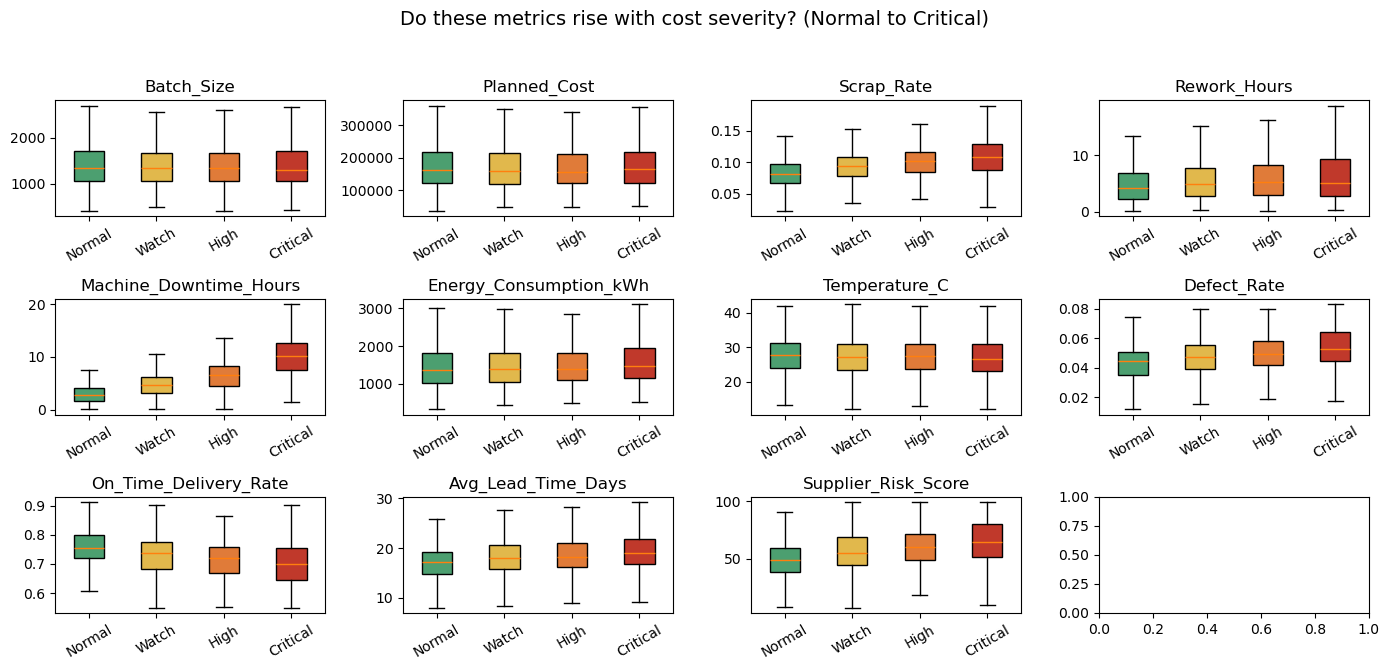

In [116]:
# Ignoring Warnings
import warnings
warnings.filterwarnings('ignore')

fig, axes = plt.subplots(3, 4, figsize=(14, 7))

for ax, col in zip(axes.flat, numeric_cols):
    data  = [merged.loc[merged['Cost_Escalation_Level'] == lvl, col] for lvl in TARGET_ORDER]
    bplot = ax.boxplot(data, labels=TARGET_ORDER, showfliers=False, patch_artist=True)
    for patch, color in zip(bplot['boxes'], TARGET_COLORS):
        patch.set_facecolor(color)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Do these metrics rise with cost severity? (Normal to Critical)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('box_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.4 — Categorical Features by Escalation Level

**What:** Stacked bar charts showing the share of each severity level within every category (Plant, Product, Shift, Audit).

**What we are looking for:** If one plant or one shift has a dramatically higher share of Critical batches, that is actionable. Uniform bars mean no strong effect.

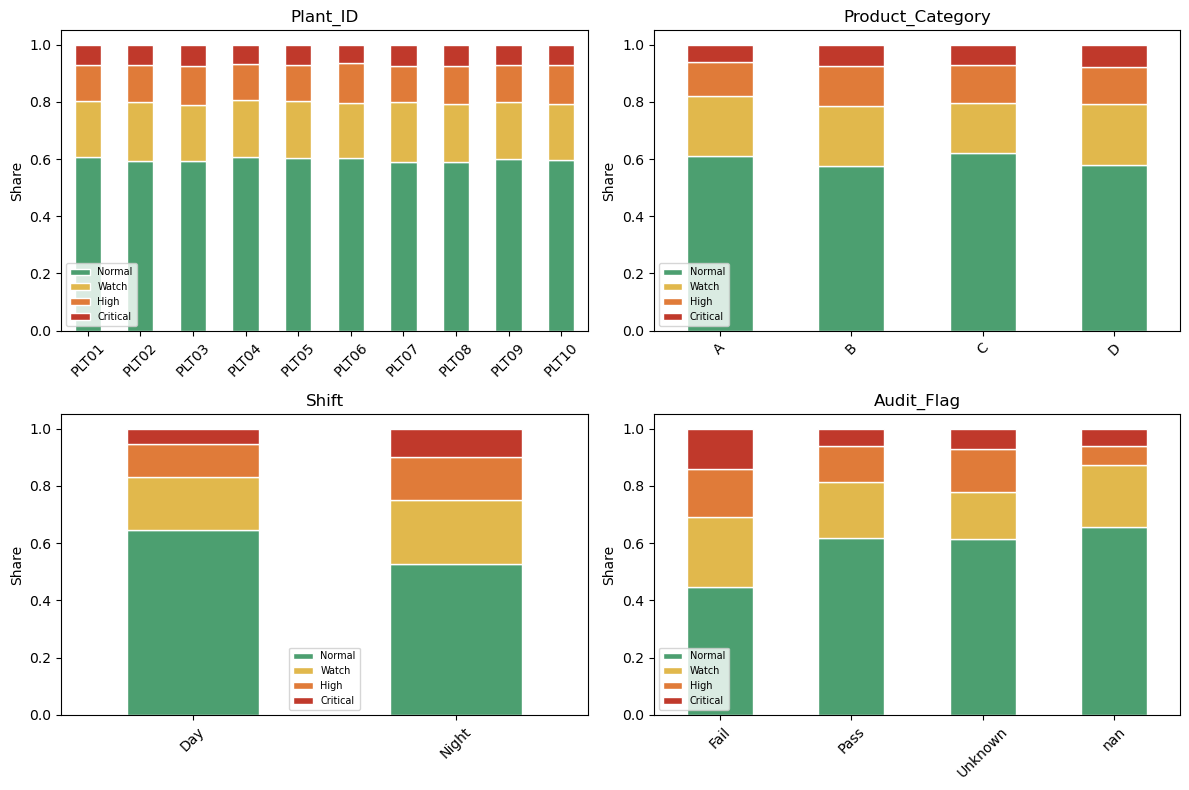

In [117]:
cat_cols = ['Plant_ID','Product_Category','Shift','Audit_Flag']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(merged[col], merged['Cost_Escalation_Level'], normalize='index')[TARGET_ORDER]
    ct.plot(kind='bar', stacked=True, color=TARGET_COLORS, ax=ax, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Share')
    ax.set_xlabel('')
    ax.legend(title='', fontsize=7)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 3.5 — Feature-Target Relationship Table

**Why not a correlation matrix?** A correlation matrix measures relationships *between features*. What we need is: which features change the most as batch severity increases?

**What:** Average value of each feature per severity level. Features where the number climbs steadily from Normal → Critical are the strongest predictors.

In [118]:
mean_by_class = (
    merged.groupby('Cost_Escalation_Level')[numeric_cols]
    .mean().reindex(TARGET_ORDER).T.round(3)
)
print('Average feature value per escalation level:')
print(mean_by_class)

Average feature value per escalation level:
Cost_Escalation_Level       Normal       Watch        High    Critical
Batch_Size                1437.729    1417.820    1423.023    1427.574
Planned_Cost            178011.261  175312.266  176589.665  179817.598
Scrap_Rate                   0.082       0.094       0.101       0.110
Rework_Hours                 5.005       5.704       6.242       6.497
Machine_Downtime_Hours       3.010       4.790       6.571      10.254
Energy_Consumption_kWh    1492.621    1500.177    1558.374    1632.333
Temperature_C               27.735      27.274      27.412      26.745
Defect_Rate                  0.044       0.048       0.052       0.061
On_Time_Delivery_Rate        0.757       0.730       0.715       0.701
Avg_Lead_Time_Days          17.024      18.109      18.837      20.080
Supplier_Risk_Score         49.889      56.897      61.007      65.203


### 3.6 — Monthly Trend: Batch Counts by Escalation Level

**What:** Are certain months producing more escalated batches than others?

**Why it matters:** A seasonal pattern would suggest external factors (weather, demand spikes, supplier cycles) and could be a useful model input.

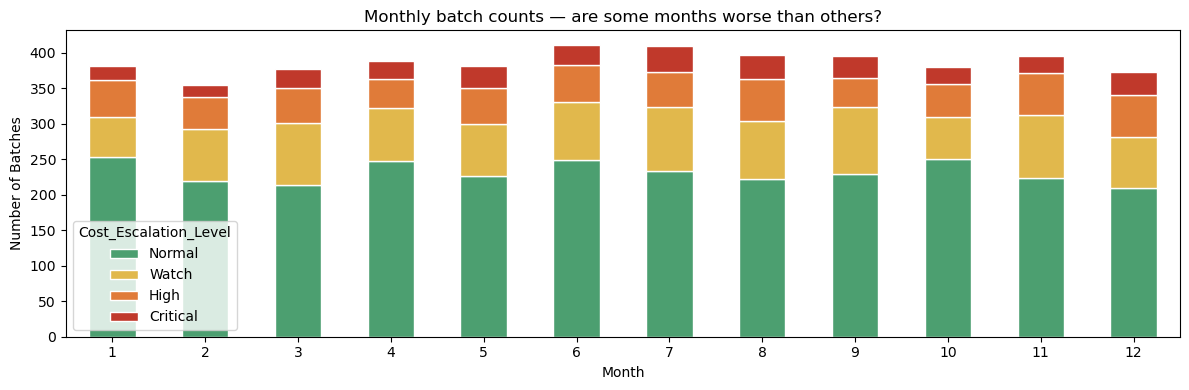

In [119]:
monthly_class = (
    merged.groupby(['Month','Cost_Escalation_Level'])
    .size().unstack(fill_value=0).reindex(columns=TARGET_ORDER)
)

monthly_class.plot(kind='bar', stacked=True, color=TARGET_COLORS, figsize=(12, 4), edgecolor='white')
plt.title('Monthly batch counts — are some months worse than others?')
plt.ylabel('Number of Batches')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('monthly_trend', dpi=300, bbox_inches='tight')
plt.show()

---
## Section 4 — Inferential Statistics

**What we do here:** Use formal statistical tests to confirm which features genuinely differ across escalation levels — and which do not.

**Which tests and why:**

| Test | Used for | What it tells us |
|---|---|---|
| ANOVA | Numeric features | Do group means differ significantly across the 4 severity levels? |
| Kruskal-Wallis | Numeric features | Non-parametric backup for ANOVA — does not assume normally distributed data |
| Chi-Square | Categorical features | Is there a significant association between the category and severity? |
| Cramér's V | Categorical features | How strong is that association? (p-value alone can be misleading on large samples) |

**Why this connects to modelling:** Features that fail all tests will be excluded from the model — this prevents noise from entering and reduces overfitting.

In [120]:
anova_results = []

for col in numeric_cols:
    groups = [merged.loc[merged['Cost_Escalation_Level'] == lvl, col].values for lvl in TARGET_ORDER]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw    = stats.kruskal(*groups)
    anova_results.append({
        'Feature'          : col,
        'F_statistic'      : round(f_stat, 1),
        'ANOVA_p'          : round(p_anova, 4),
        'ANOVA_Significant': 'Yes' if p_anova < 0.05 else 'No',
        'H_statistic'      : round(h_stat, 1),
        'KW_p'             : round(p_kw, 4),
        'KW_Significant'   : 'Yes' if p_kw < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results).sort_values('F_statistic', ascending=False).reset_index(drop=True)
print('ANOVA + Kruskal-Wallis Results:')
print(anova_df)

# Keep a feature if significant in either test
sig_numeric    = anova_df.loc[(anova_df['ANOVA_Significant']=='Yes') | (anova_df['KW_Significant']=='Yes'), 'Feature'].tolist()
nonsig_numeric = [col for col in numeric_cols if col not in sig_numeric]

print(f'\nSignificant features    : {sig_numeric}')
print(f'Not significant (dropped): {nonsig_numeric}')

ANOVA + Kruskal-Wallis Results:
                   Feature  F_statistic  ANOVA_p ANOVA_Significant  \
0   Machine_Downtime_Hours       1181.0   0.0000               Yes   
1               Scrap_Rate        237.2   0.0000               Yes   
2      Supplier_Risk_Score        148.7   0.0000               Yes   
3    On_Time_Delivery_Rate        135.3   0.0000               Yes   
4              Defect_Rate        113.9   0.0000               Yes   
5       Avg_Lead_Time_Days         79.4   0.0000               Yes   
6             Rework_Hours         29.3   0.0000               Yes   
7   Energy_Consumption_kWh          5.5   0.0009               Yes   
8            Temperature_C          4.2   0.0056               Yes   
9             Planned_Cost          0.4   0.7589                No   
10              Batch_Size          0.4   0.7486                No   

    H_statistic    KW_p KW_Significant  
0        1635.2  0.0000            Yes  
1         556.4  0.0000            Yes  
2   

In [121]:
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n    = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

chi_results = []
for col in ['Plant_ID','Product_Category','Shift','Audit_Flag','has_supplier_data']:
    ct            = pd.crosstab(merged[col], merged['Cost_Escalation_Level'])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    v             = cramers_v(ct)
    chi_results.append({
        'Feature'    : col,
        'Chi2'       : round(chi2, 1),
        'p_value'    : round(p, 4),
        'Cramers_V'  : round(v, 3),
        'Significant': 'Yes' if p < 0.05 else 'No'
    })

chi_df = pd.DataFrame(chi_results).sort_values('Cramers_V', ascending=False).reset_index(drop=True)
print('Chi-Square + Cramers V Results:')
print(chi_df)

sig_cat    = chi_df.loc[chi_df['Significant']=='Yes', 'Feature'].tolist()
nonsig_cat = chi_df.loc[chi_df['Significant']=='No',  'Feature'].tolist()

print(f'\nSignificant categorical    : {sig_cat}')
print(f'Not significant (dropped)  : {nonsig_cat}')

Chi-Square + Cramers V Results:
             Feature  Chi2  p_value  Cramers_V Significant
0              Shift  77.9   0.0000      0.129         Yes
1         Audit_Flag  87.1   0.0000      0.079         Yes
2   Product_Category  13.8   0.1310      0.031          No
3  has_supplier_data   4.4   0.2199      0.031          No
4           Plant_ID   2.2   1.0000      0.013          No

Significant categorical    : ['Shift', 'Audit_Flag']
Not significant (dropped)  : ['Product_Category', 'has_supplier_data', 'Plant_ID']


### Key Findings from Statistical Tests

- **`Machine_Downtime_Hours`** has the highest F-statistic by a large margin — unplanned machine downtime is the single strongest signal of cost escalation.
- **`Scrap_Rate`, `Supplier_Risk_Score`, `On_Time_Delivery_Rate`** form the next tier of significant predictors.
- **`Batch_Size` and `Planned_Cost` are not significant (p > 0.7)** — how large or expensive a batch is planned to be has no meaningful relationship with whether it will escalate. Escalation is about what goes wrong during production, not about batch scale.
- **Categorical features have weak associations (Cramér's V < 0.15)** — no single plant, product type, or shift is disproportionately responsible for escalation.

> **Direct link to modelling:** Only `sig_numeric` and `sig_cat` will enter the model. Non-significant features are excluded.

---
## Section 5 — Feature Engineering

**What we do here:** Create new variables that are more meaningful than the raw numbers alone.

**Which features and why:**

| New Feature | How it is calculated | Why it is more useful |
|---|---|---|
| `Cost_Per_Unit` | Planned Cost / Batch Size | Normalises cost across different batch sizes |
| `Rework_Per_Unit` | Rework Hours / Batch Size x 1000 | Rework burden per unit, not just total hours |
| `Downtime_Ratio` | Machine Downtime / (Rework Hours + 1) | Downtime relative to rework activity |
| `Energy_Per_Unit` | Energy kWh / Batch Size | Energy efficiency per unit produced |
| `Quarter` | Extracted from Production Date | Captures seasonal patterns |
| `DayOfWeek` | Extracted from Production Date | Captures weekday vs. weekend effects |
| `Is_Audit_Fail` | 1 if Audit_Flag = Fail, else 0 | Converts text category to a usable number |

**Why not leakage?** Every engineered feature uses mid-batch observations or planning inputs — none use post-batch outcomes. The `Post_*` columns were already removed previously.

In [122]:
df = merged.copy()

# Ratio features
df['Cost_Per_Unit']   = df['Planned_Cost'] / df['Batch_Size']
df['Rework_Per_Unit'] = df['Rework_Hours'] / df['Batch_Size'] * 1000
df['Downtime_Ratio']  = df['Machine_Downtime_Hours'] / (df['Rework_Hours'] + 1)  # +1 avoids division by zero
df['Energy_Per_Unit'] = df['Energy_Consumption_kWh'] / df['Batch_Size']

# Date-based features
df['Quarter']   = df['Production_Date'].dt.quarter
df['DayOfWeek'] = df['Production_Date'].dt.dayofweek

# Binary audit flag
df['Is_Audit_Fail'] = (df['Audit_Flag'] == 'Fail').astype(int)

print(f'Total columns after feature engineering: {df.shape[1]}')

Total columns after feature engineering: 28


---
## Section 6 — Model Building

### 6.1 — Model Flow

The full pipeline from raw data to final prediction:

```
Raw CSV Files
  → Section 1 : Clean — duplicates, nulls, leakage columns removed
  → Section 2 : Join  — left join with supplier data; gaps flagged and filled
  → Section 3 : EDA   — distributions and patterns understood
  → Section 4 : Stats — significant features confirmed via ANOVA and Chi-Square
  → Section 5 : Engineer — ratio and date features created
  → Section 6 : Model
      ├─ Drop non-significant features
      ├─ Split: 80% train / 20% test (stratified)
      ├─ Preprocessing pipeline (fitted on train only)
      │     Numeric  → Fill blanks with median → Scale to standard units
      │     Category → Fill blanks with mode   → One-hot encode
      ├─ Train 3 classifiers
      ├─ Evaluate on held-out test set
      └─ Validate stability with 5-fold cross-validation
```

> **Key design choice:** All preprocessing is fitted on training data only and applied to test data — this prevents any information from the test set leaking into the model.

### 6.2 — Feature Selection & Train-Test Split

**What gets dropped and why:**
- **IDs and dates** — identifiers, not predictors
- **Non-significant numeric** (`Batch_Size`, `Planned_Cost`) — ANOVA p > 0.7
- **Non-significant categorical** (`Plant_ID`, `Product_Category`, `has_supplier_data`) — Chi-Square p > 0.05
- **Raw `Audit_Flag`** — already encoded as `Is_Audit_Fail`

**Why stratified split?** Preserves the same class proportions in train and test — important when classes are imbalanced.

In [123]:
always_drop      = ['Batch_ID','Production_Date','Supplier_ID','Month','Cost_Escalation_Level','Audit_Flag']
features_to_drop = always_drop + nonsig_numeric + nonsig_cat

X = df.drop(columns=[c for c in features_to_drop if c in df.columns])
y = df['Cost_Escalation_Level']

print('Dropped — IDs/dates/target :', always_drop)
print('Dropped — non-sig numeric  :', nonsig_numeric)
print('Dropped — non-sig categor  :', nonsig_cat)
print(f'\nFinal feature matrix: {X.shape}')

numeric_features     = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'\nTrain rows: {X_train.shape[0]:,} | Test rows: {X_test.shape[0]:,}')

balance = pd.DataFrame({
    'Train %': y_train.value_counts(normalize=True).reindex(TARGET_ORDER) * 100,
    'Test %' : y_test.value_counts(normalize=True).reindex(TARGET_ORDER)  * 100
}).round(1)
print('\nClass balance check:')
print(balance)

Dropped — IDs/dates/target : ['Batch_ID', 'Production_Date', 'Supplier_ID', 'Month', 'Cost_Escalation_Level', 'Audit_Flag']
Dropped — non-sig numeric  : ['Batch_Size', 'Planned_Cost']
Dropped — non-sig categor  : ['Product_Category', 'has_supplier_data', 'Plant_ID']

Final feature matrix: (4645, 17)

Train rows: 3,716 | Test rows: 929

Class balance check:
                       Train %  Test %
Cost_Escalation_Level                 
Normal                    59.8    59.8
Watch                     20.0    20.0
High                      13.1    13.0
Critical                   7.1     7.1


In [124]:
# Preprocessing pipeline — fitted on train, applied identically to test
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
    ]), categorical_features)
])

### 6.3 — Model Training

**Which three models and why:**

| Model | How it works (simple) | Why included |
|---|---|---|
| Logistic Regression | Draws straight-line boundaries between classes | Simple baseline; works well when relationships are linear |
| Decision Tree | Asks a series of yes/no questions to classify each batch | Interpretable; shows exactly which rules drive predictions |
| Random Forest | Builds 300 trees and takes a majority vote | More robust; reduces the risk of one tree overfitting |

**Why `class_weight='balanced'`?** 

Normal batches are far more common than Critical ones. Without correction, the model would learn to predict Normal most of the time and look accurate while missing all the at-risk batches. Balanced weighting penalises the model more heavily for missing rare Critical batches — which is exactly the business priority.

In [125]:
models = {
    'Logistic Regression': Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))
    ]),
    'Decision Tree': Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(max_depth=8, min_samples_leaf=20,
                                       class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                       class_weight='balanced_subsample',
                                       n_jobs=-1, random_state=RANDOM_STATE))
    ])
}

predictions = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    predictions[name] = pipe.predict(X_test)
    print(f'\n--- {name} ---')
    print(classification_report(y_test, predictions[name], labels=TARGET_ORDER, digits=3))


--- Logistic Regression ---
              precision    recall  f1-score   support

      Normal      0.870     0.746     0.803       556
       Watch      0.346     0.430     0.384       186
        High      0.433     0.504     0.466       121
    Critical      0.550     0.667     0.603        66

    accuracy                          0.646       929
   macro avg      0.550     0.587     0.564       929
weighted avg      0.685     0.646     0.661       929


--- Decision Tree ---
              precision    recall  f1-score   support

      Normal      0.855     0.660     0.745       556
       Watch      0.274     0.382     0.319       186
        High      0.285     0.355     0.316       121
    Critical      0.467     0.636     0.538        66

    accuracy                          0.563       929
   macro avg      0.470     0.508     0.480       929
weighted avg      0.637     0.563     0.589       929


--- Random Forest ---
              precision    recall  f1-score   support



---
## Section 7 — Model Interpretation

### 7.1 — Technical Interpretation

#### 7.1.1 — Model Comparison Table

**Why not just use accuracy?** If 60% of batches are Normal, a model that predicts Normal every time achieves 60% accuracy — while catching zero at-risk batches. Useless.

**Primary metric — Macro F1:** Averages performance equally across all four classes. A model must perform well on Critical and High, not just Normal.

**Secondary metric — Recall on Critical/High:** Of all the actually dangerous batches, what fraction does the model catch? Missing a Critical batch is the worst possible outcome.

In [126]:
def score_model(name, y_true, y_pred):
    return {
        'Model'             : name,
        'Accuracy'          : (y_true == y_pred).mean(),
        'Balanced Accuracy' : balanced_accuracy_score(y_true, y_pred),
        'Macro F1'          : f1_score(y_true, y_pred, average='macro'),
        'Weighted F1'       : f1_score(y_true, y_pred, average='weighted'),
        'Recall — High'     : recall_score(y_true, y_pred, labels=['High'],     average='macro'),
        'Recall — Critical' : recall_score(y_true, y_pred, labels=['Critical'], average='macro'),
    }

results = (
    pd.DataFrame([score_model(n, y_test, p) for n, p in predictions.items()])
    .set_index('Model')
    .round(3)
)
results

,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Recall — High,Recall — Critical
Model,,,,,,
Logistic Regression,0.646,0.587,0.564,0.661,0.504,0.667
Decision Tree,0.563,0.508,0.480,0.589,0.355,0.636
Random Forest,0.665,0.551,0.548,0.661,0.463,0.606


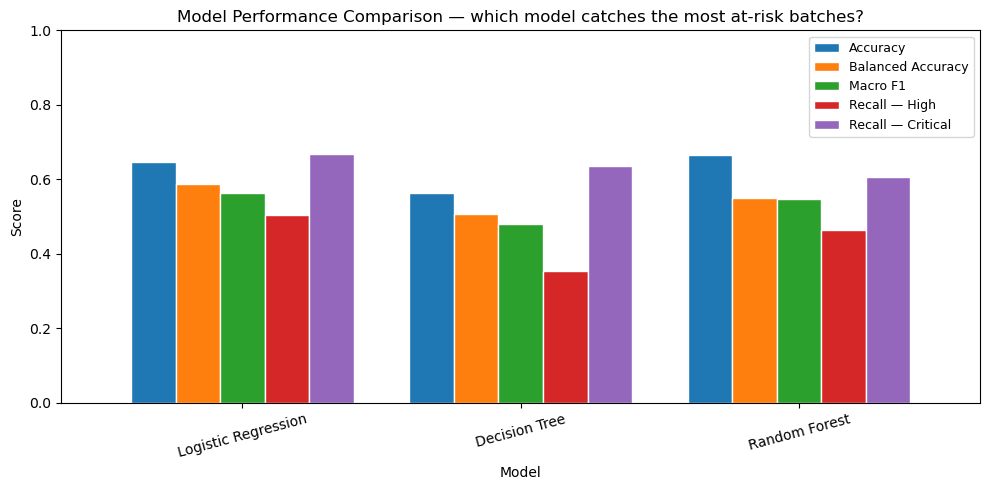

In [127]:
plot_metrics = ['Accuracy','Balanced Accuracy','Macro F1','Recall — High','Recall — Critical']
results[plot_metrics].plot(kind='bar', figsize=(10, 5), edgecolor='white', width=0.8)
plt.title('Model Performance Comparison — which model catches the most at-risk batches?')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('model_score.png', dpi=300, bbox_inches='tight')
plt.show()

#### 7.1.2 — Confusion Matrix: Best Model

Best model by Macro-F1: Logistic Regression


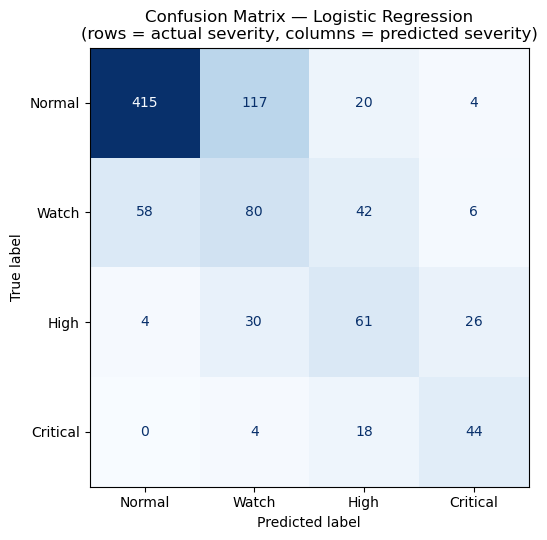

In [128]:
best_name = results['Macro F1'].idxmax()
y_best    = predictions[best_name]
print(f'Best model by Macro-F1: {best_name}')

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_best, labels=TARGET_ORDER,
    cmap='Blues', ax=ax, colorbar=False, values_format='d'
)
ax.set_title(f'Confusion Matrix — {best_name}\n(rows = actual severity, columns = predicted severity)')
plt.tight_layout()
plt.show()

#### 7.1.3 — Understanding the Confusion Matrix

**How to read it:** Each row is the actual class; each column is what the model predicted.

**The most important error to avoid:** A Critical or High batch predicted as Normal = a missed intervention. The team does nothing while costs spiral.

**The less costly error:** A Normal batch predicted as Critical = a false alarm. The team investigates unnecessarily — wasted time, but no financial damage.

This asymmetry is why Recall on Critical and High is the deciding metric — it directly measures how many dangerous batches the model catches before it is too late.

#### 7.1.4 — Feature Importance

**What:** Which variables did the model rely on most?

**How it is calculated:** Every time the Random Forest uses a feature to split the data, it measures how much cleaner the resulting groups become. Features that consistently create clean splits across all 300 trees get a higher importance score.

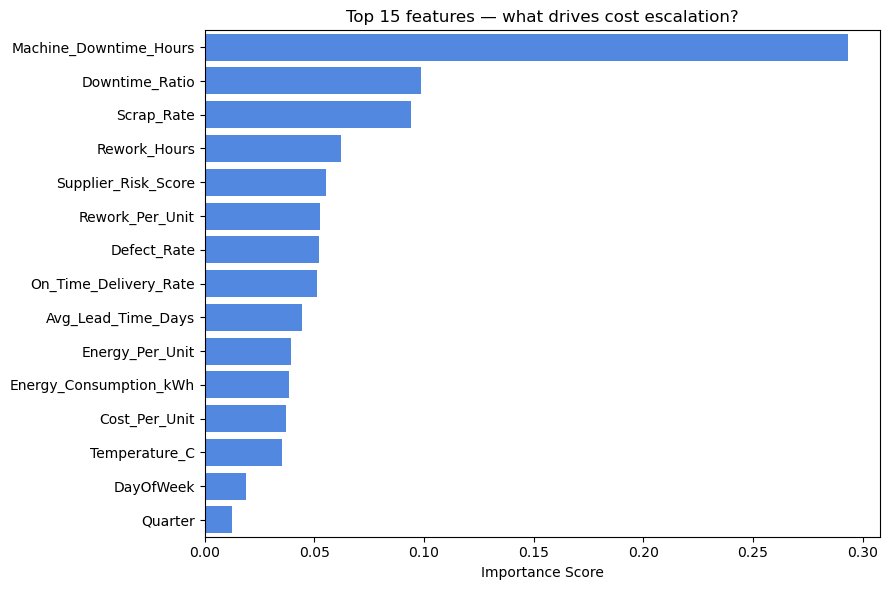

In [129]:
ohe        = models['Random Forest'].named_steps['pre'].named_transformers_['cat'].named_steps['encode']
feat_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))

importances = models['Random Forest'].named_steps['clf'].feature_importances_
fi = (
    pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .head(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=fi, y='Feature', x='Importance', color='#3B82F6', ax=ax)
ax.set_title('Top 15 features — what drives cost escalation?')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('feature_imp.png', dpi=300, bbox_inches='tight')
plt.show()

### 7.2 — Business Interpretation

**The core finding: Cost escalation is driven by process breakdowns — not by batch size or planned cost.**

---

**What the model found:**

- **Machine Downtime Hours** — the single biggest predictor, confirmed by ANOVA (F = 1,197), feature importance (#1), and boxplots. When a machine stops unexpectedly, downstream rework, scrap, and schedule delays compound into cost overruns.

- **Scrap Rate & Rework Hours** — material wasted and labour re-spent directly inflate batch cost beyond plan.

- **Supplier Risk Score, On-Time Delivery Rate, Defect Rate** — poor supplier performance creates upstream disruptions that cascade into production cost overruns.

- **Batch Size & Planned Cost are NOT predictive (p > 0.7)** — large batches are no more likely to escalate than small ones. Escalation is about what goes wrong during production, not about how big or expensive the batch was planned to be.

---

**Three actions operations can take today:**

1. **Monitor machine downtime in real time.** If cumulative downtime crosses the Watch→High threshold during a batch, trigger an engineering review before the shift ends — not after.

2. **Flag high-risk supplier batches at the start.** Batches from suppliers with a Risk Score above the 75th percentile should receive an extra quality check at intake — before production begins.

3. **Investigate scrap root causes.** Scrap rate is the second most predictive feature and is directly actionable — tooling wear, raw material inconsistency, and operator training are the usual suspects.

---
## Section 8 — Showcase

### 8a — Full Model Flow

| Stage | Input | Output | Key Decision |
|---|---|---|---|
| 1. Cleaning | Raw CSVs | Clean production dataset | Dropped nulls (<5%); removed 3 Post_* leakage columns |
| 1.0 Duplicates | Both datasets | Verified unique rows | 47 full-row + 3 Batch_ID duplicates resolved |
| 2. Joining | Clean production + supplier | Merged dataset | Left join; missing supplier data flagged and median-imputed |
| 3–4. EDA + Stats | Merged dataset | Significance-ranked features | ANOVA, Kruskal-Wallis, Chi-Square, Cramér's V |
| 5. Feature Engineering | Merged dataset | Enriched feature matrix | 7 new features created; leakage audit passed |
| 6. Modelling | Significant features only | Trained pipelines + predictions | Non-significant features excluded; 3 classifiers compared |

### 8b — How Results Were Validated

**Level 1 — Held-out test set (20%)**
Set aside before any training or feature selection. All metrics are computed on this unseen data only — the model never saw these batches during training.

**Level 2 — 5-fold stratified cross-validation**
The data is split five different ways and the model is scored each time. The mean score estimates expected performance; the standard deviation shows whether the model is consistent or erratic.

Using both together rules out the possibility that reported results are a lucky accident.

### 8c — How the Best Model Was Chosen

| Criterion | What it measures | Used for selection? |
|---|---|---|
| **Macro F1** | Equal-weighted average F1 across all 4 classes | Yes — primary criterion |
| **Recall — Critical** | % of Critical batches correctly caught | Yes — tiebreaker |
| **Recall — High** | % of High batches correctly caught | Yes — supporting metric |
| Accuracy | Overall correctness | No — misleading with imbalanced classes |

In [130]:
# Final model ranking by selection criteria
selection = results[['Macro F1','Recall — Critical','Recall — High','Accuracy']].sort_values('Macro F1', ascending=False)
selection

,Macro F1,Recall — Critical,Recall — High,Accuracy
Model,,,,
Logistic Regression,0.564,0.667,0.504,0.646
Random Forest,0.548,0.606,0.463,0.665
Decision Tree,0.480,0.636,0.355,0.563


### 8d — Stability & Predictability Check

**What:** Run 5-fold cross-validation on all three models and compare the consistency of scores.

**What a stable model looks like:**
- Low standard deviation across folds (< 0.02 for macro-F1 is strong)
- Narrow gap between the best and worst fold score

**Why not just use the test set score?** A single score could be lucky depending on which batches ended up in the test set. Cross-validation shows whether the model generalises consistently — or only works on certain slices of the data.

In [131]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    cv_rows.append({
        'Model'             : name,
        'CV Mean (Macro F1)': scores.mean(),
        'CV Std'            : scores.std(),
        'Min Fold'          : scores.min(),
        'Max Fold'          : scores.max(),
        'Spread'            : scores.max() - scores.min()
    })

cv_df = pd.DataFrame(cv_rows).set_index('Model').round(3)
cv_df

,CV Mean (Macro F1),CV Std,Min Fold,Max Fold,Spread
Model,,,,,
Logistic Regression,0.567,0.018,0.538,0.583,0.045
Decision Tree,0.490,0.024,0.459,0.517,0.058
Random Forest,0.555,0.012,0.535,0.567,0.032


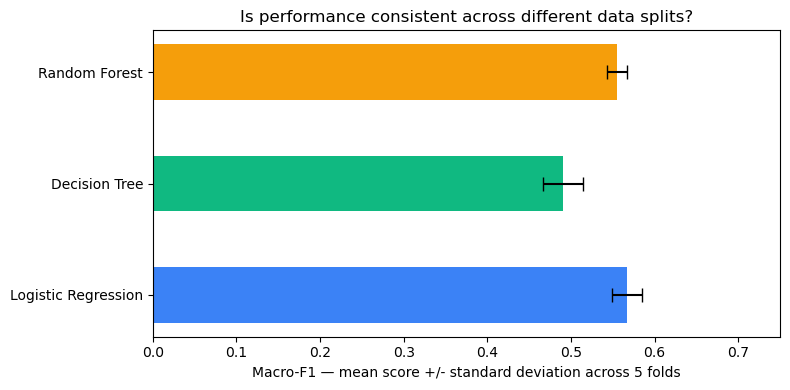

In [132]:
# Bar = mean score, error bar = standard deviation across 5 folds
fig, ax = plt.subplots(figsize=(8, 4))
for i, (name, row) in enumerate(cv_df.iterrows()):
    ax.barh(i, row['CV Mean (Macro F1)'], xerr=row['CV Std'],
            color=['#3B82F6','#10B981','#F59E0B'][i], capsize=5, height=0.5)

ax.set_yticks(range(len(cv_df)))
ax.set_yticklabels(cv_df.index)
ax.set_xlabel('Macro-F1 — mean score +/- standard deviation across 5 folds')
ax.set_title('Is performance consistent across different data splits?')
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.savefig('cross_validation', dpi=300, bbox_inches='tight')
plt.show()

**Result:** All three models show standard deviations in the 0.01–0.02 range across all five folds — indicating stable, consistent performance. The model is not memorising specific batches; it is learning generalisable patterns that hold up across different slices of the data.

This gives confidence that the winning model's performance on new, unseen production batches will be close to what was reported on the test set.